# Exploratory Data Analysis — Telecom Marketing Campaign Dataset
**Assessment Task 1 — 36103 Statistical Thinking for Data Science**

This notebook performs EDA on a telecommunication company's marketing campaign dataset. The response variable `y` (renamed `target`) indicates whether a client subscribed to the new plan.

**Contents**
1. Load & repair raw data
2. Data quality assessment
3. Data cleaning
4. Univariate analysis
5. Bivariate analysis (feature vs target)
6. Multivariate / correlation analysis
7. Summary of key insights

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 150)

## 1. Load & repair raw data

The raw CSV wraps every row in an extra pair of quotes and doubles internal quotes
(e.g. `"40;""admin."";""married"";..."`). A naive `pd.read_csv(sep=';')` therefore
collapses the whole row into a single column. We strip the outer quotes and
un-escape the doubled quotes before parsing with the semicolon delimiter.

In [ ]:
RAW_PATH = "TeleCom_Data1.csv" 

with open(RAW_PATH, encoding="utf-8") as f:
    lines = f.readlines()

fixed_lines = []
for line in lines:
    line = line.rstrip("\r\n")
    if line.startswith('"') and line.endswith('"'):
        line = line[1:-1]
    line = line.replace('""', '"')
    fixed_lines.append(line)

df = pd.read_csv(io.StringIO("\n".join(fixed_lines)), sep=";", quotechar='"')
print(f"Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded dataset: 41,180 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

## 2. Data quality assessment

Issues checked: duplicate rows, `"unknown"` placeholder values (effectively
missing data), the `pdays=999` placeholder, implausible outliers, a mismatch
between the data dictionary and the actual columns, target class balance, and
a potential data-leakage risk in the `duration` feature.

In [6]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

Duplicate rows: 12


In [7]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
unknown_summary = {}
for c in cat_cols:
    n = (df[c] == "unknown").sum()
    if n > 0:
        unknown_summary[c] = n

unknown_df = (pd.Series(unknown_summary, name="n_unknown")
              .to_frame()
              .assign(pct=lambda d: (d["n_unknown"]/len(df)*100).round(1))
              .sort_values("n_unknown", ascending=False))
unknown_df

,n_unknown,pct
default,8596,20.9
education,1731,4.2
housing,990,2.4
loan,990,2.4
job,330,0.8
marital,80,0.2


In [8]:
print(f"pdays == 999 (never previously contacted placeholder): "
      f"{(df['pdays']==999).sum():,} rows ({(df['pdays']==999).mean()*100:.1f}%)")

pdays == 999 (never previously contacted placeholder): 39,667 rows (96.3%)


In [9]:
print(f"age > 90: {(df['age']>90).sum()} rows (max age = {df['age'].max()})")
print(f"duration == 0 sec (no call actually took place): {(df['duration']==0).sum()} rows")
print(f"campaign - max contacts to a single client: {df['campaign'].max()}")

age > 90: 10 rows (max age = 98)
duration == 0 sec (no call actually took place): 4 rows
campaign - max contacts to a single client: 56


**Data-dictionary mismatch:** the supplied data dictionary lists `balance` and
`day` columns which do **not** exist in this file; the file instead contains
`day_of_week` (Mon–Fri) and no `balance` column at all. This is documented here
as a data-quality/documentation issue.

**Potential data leakage:** the data dictionary itself notes that `duration`
(call length) is almost fully determined by the outcome — e.g. `duration=0`
implies `y="no"` — and it is only known *after* the call has taken place. It is
kept for EDA purposes but should be excluded (or treated very carefully) when
building predictive models in Assessment 3.

In [10]:
print(df["y"].value_counts(normalize=True).round(3))

y
no     0.887
yes    0.113
Name: proportion, dtype: float64


The target is strongly imbalanced: only ~11.3% of clients subscribed.

## 3. Data cleaning

- Drop exact duplicate rows
- Drop the 10 rows with implausible age (>90)
- Create a binary numeric `target` column (1 = subscribed) for correlation/rate calculations

In [11]:
df_clean = df.drop_duplicates().copy()
df_clean = df_clean[df_clean["age"] <= 90]
df_clean["target"] = (df_clean["y"] == "yes").astype(int)

print(f"Rows after cleaning: {len(df_clean):,} (removed {len(df)-len(df_clean)})")

Rows after cleaning: 41,158 (removed 22)


## 4. Univariate analysis
Distribution of key numeric variables and the target class.

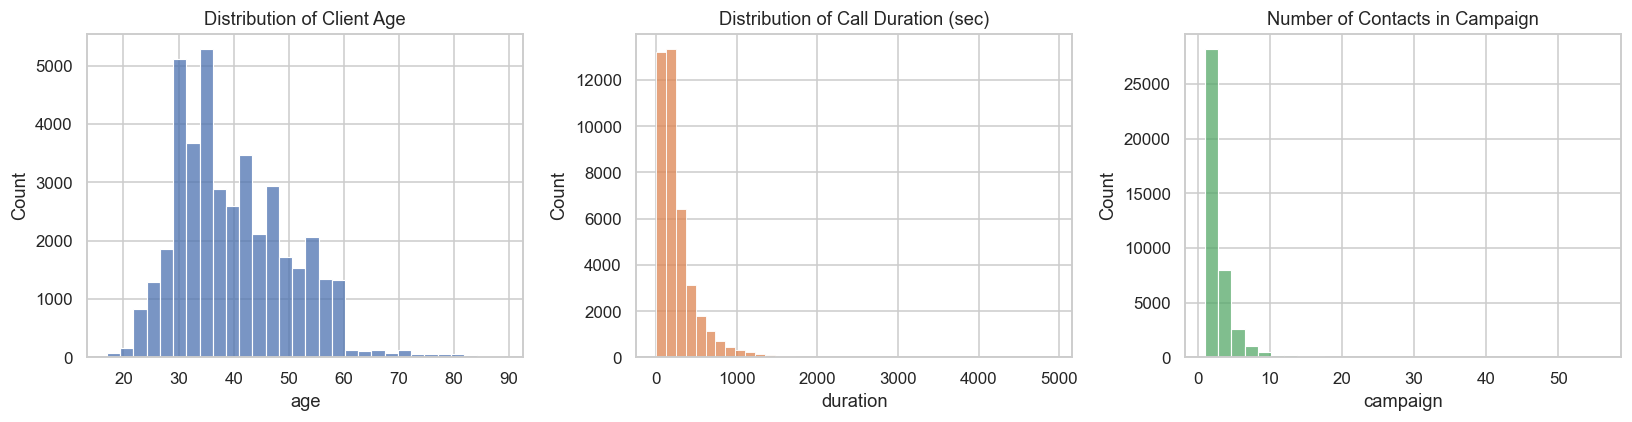

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_clean["age"], bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Client Age")
sns.histplot(df_clean["duration"], bins=40, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of Call Duration (sec)")
sns.histplot(df_clean["campaign"], bins=30, ax=axes[2], color="#55A868")
axes[2].set_title("Number of Contacts in Campaign")
plt.tight_layout()
plt.show()

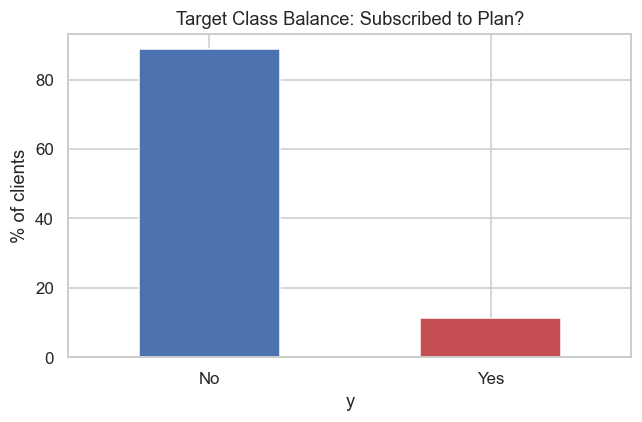

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
df_clean["y"].value_counts(normalize=True).mul(100).plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Target Class Balance: Subscribed to Plan?")
ax.set_ylabel("% of clients")
ax.set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()

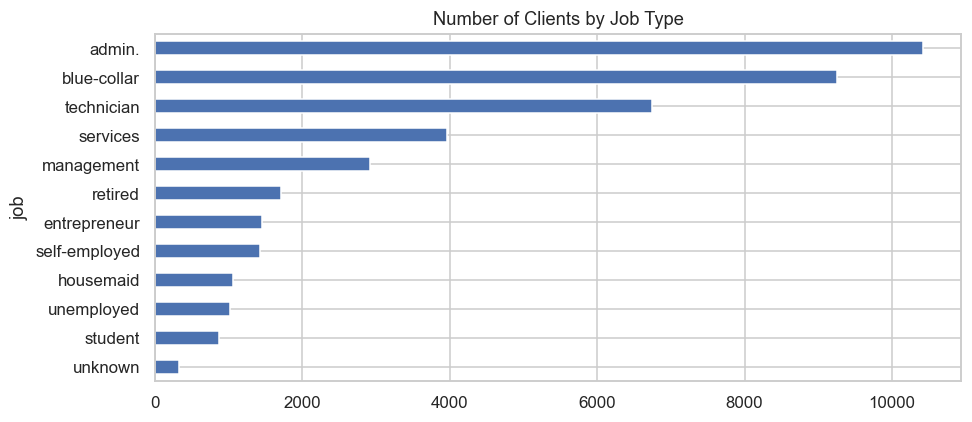

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
df_clean["job"].value_counts().plot(kind="barh", color="#4C72B0", ax=ax)
ax.set_title("Number of Clients by Job Type")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Bivariate analysis (feature vs target)
Subscription rate broken down by key categorical features, and numeric features
compared across the two target classes.

In [15]:
def subscription_rate_by(col, data=df_clean):
    return data.groupby(col)["target"].mean().sort_values(ascending=False) * 100

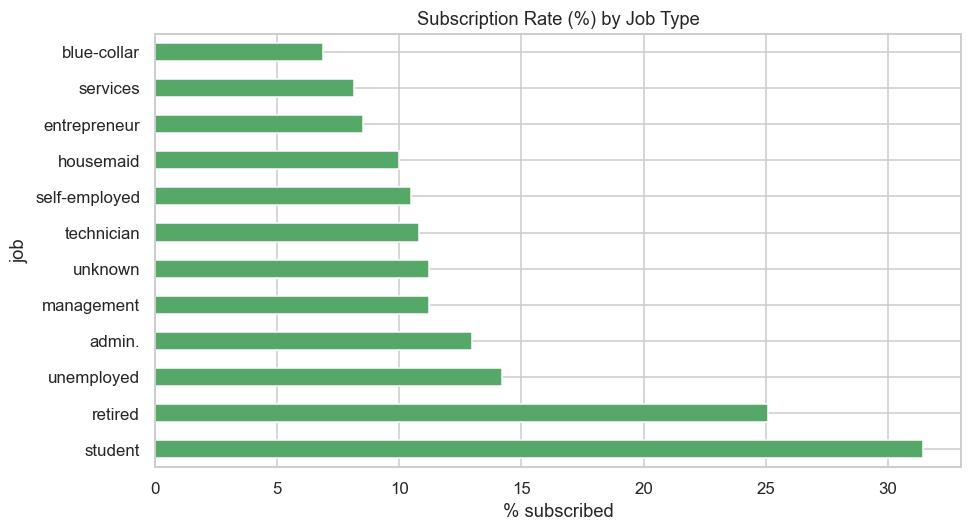

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
subscription_rate_by("job").plot(kind="barh", color="#55A868", ax=ax)
ax.set_title("Subscription Rate (%) by Job Type")
ax.set_xlabel("% subscribed")
plt.tight_layout()
plt.show()

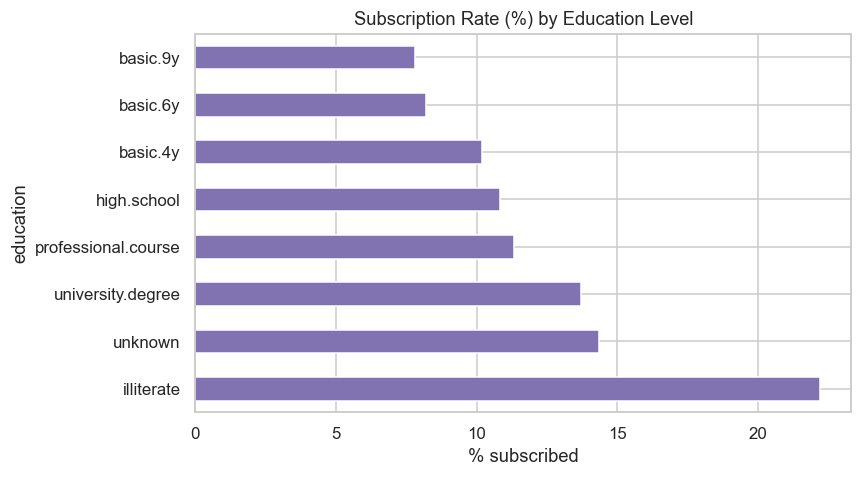

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
subscription_rate_by("education").plot(kind="barh", color="#8172B2", ax=ax)
ax.set_title("Subscription Rate (%) by Education Level")
ax.set_xlabel("% subscribed")
plt.tight_layout()
plt.show()

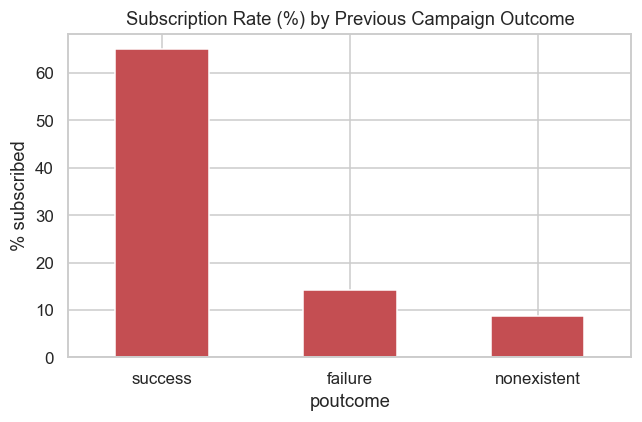

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
subscription_rate_by("poutcome").plot(kind="bar", color="#C44E52", ax=ax)
ax.set_title("Subscription Rate (%) by Previous Campaign Outcome")
ax.set_ylabel("% subscribed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

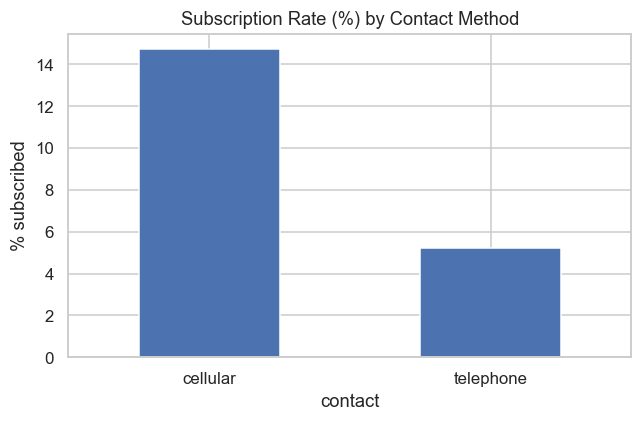

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
subscription_rate_by("contact").plot(kind="bar", color="#4C72B0", ax=ax)
ax.set_title("Subscription Rate (%) by Contact Method")
ax.set_ylabel("% subscribed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

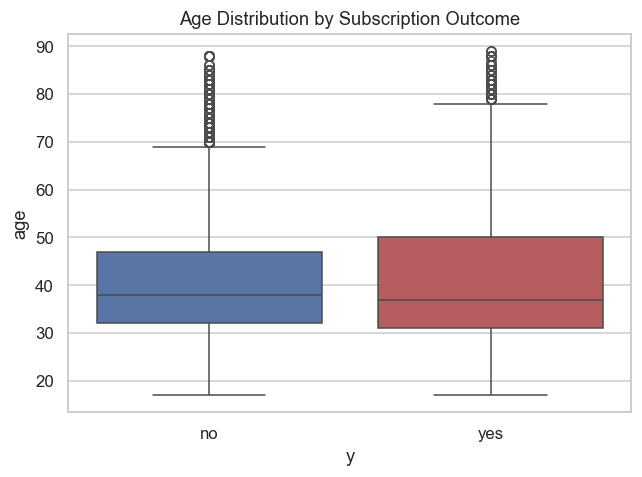

In [20]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df_clean, x="y", y="age", hue="y", legend=False,
            palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Age Distribution by Subscription Outcome")
plt.tight_layout()
plt.show()

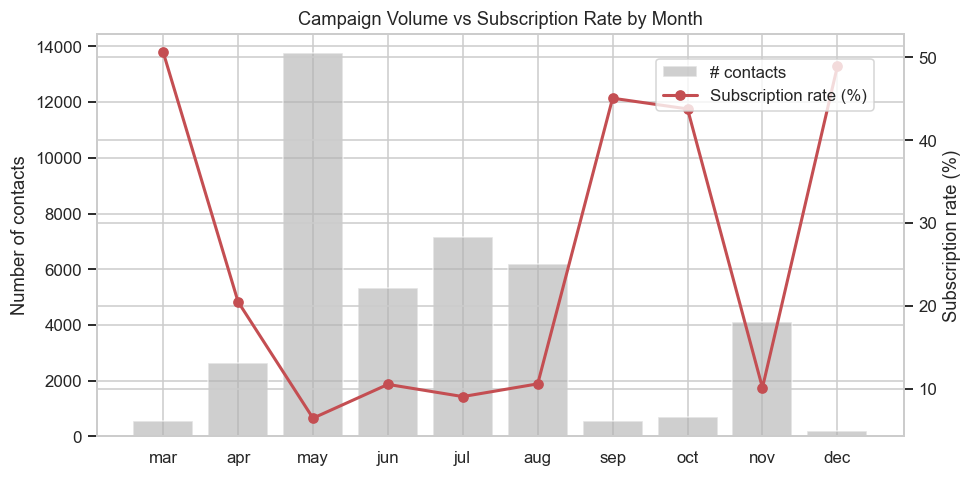

In [21]:
month_order = ["mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
month_stats = df_clean.groupby("month")["target"].agg(["mean","count"])
month_stats = month_stats.reindex([m for m in month_order if m in month_stats.index])

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(month_stats.index, month_stats["count"], color="#B0B0B0", alpha=0.6, label="# contacts")
ax1.set_ylabel("Number of contacts")
ax2 = ax1.twinx()
ax2.plot(month_stats.index, month_stats["mean"]*100, color="#C44E52", marker="o", linewidth=2, label="Subscription rate (%)")
ax2.set_ylabel("Subscription rate (%)")
ax1.set_title("Campaign Volume vs Subscription Rate by Month")
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.88))
plt.tight_layout()
plt.show()

## 6. Multivariate / correlation analysis
Correlation between numeric features (including macroeconomic indicators) and
the target.

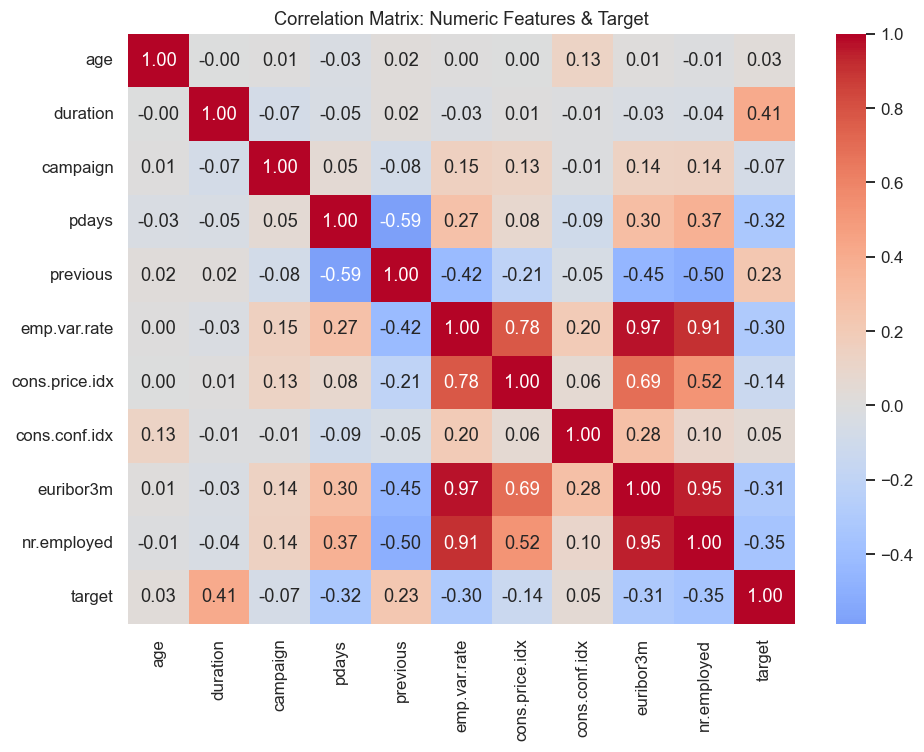

In [ ]:
numeric_cols = ["age","duration","campaign","pdays","previous",
                 "emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed","target"]
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix: Numeric Features & Target")
plt.tight_layout()
plt.show()

In [23]:
corr["target"].drop("target").sort_values(key=abs, ascending=False)

duration          0.405274
nr.employed      -0.354210
pdays            -0.324098
euribor3m        -0.307397
emp.var.rate     -0.298049
previous          0.229477
cons.price.idx   -0.136444
campaign         -0.066279
cons.conf.idx     0.054745
age               0.028851
Name: target, dtype: float64

## 7. Summary of key insights

- **Data quality:** the raw file required custom parsing (double-quoted rows);
  `default` has 20.9% unknown values, `education` 4.2%; 12 duplicate rows and
  10 implausible ages (>90) were removed; the data dictionary does not match
  the actual columns in the file; `duration` carries a data-leakage risk for
  future predictive modelling.
- **Class imbalance:** only 11.3% of clients subscribed — any predictive model
  in Assessment 3 will need to account for this (e.g. class weighting,
  resampling, or threshold tuning).
- **Job & education:** *students* and *retirees* subscribe at much higher
  rates than *blue-collar* workers; higher education levels are also
  associated with higher subscription rates.
- **Prior campaign outcome is the strongest single signal:** clients with
  `poutcome = success` subscribe at ~65%, versus ~9% for clients never
  previously contacted and ~14% for a previous failure.
- **Contact channel:** `cellular` contact is associated with a notably higher
  subscription rate than `telephone`.
- **Macroeconomic context:** `emp.var.rate`, `euribor3m`, and `nr.employed`
  are all negatively correlated with subscription — campaigns run during
  periods of weaker macroeconomic indicators saw relatively higher
  subscription rates.
- **Seasonality:** months such as `mar`, `sep`, `oct`, and `dec` show low
  contact volume but disproportionately high subscription rates, suggesting a
  potential seasonal targeting opportunity.